# Random Forest — Diabetes 30-Day Readmission

**Author:** Om Prajapati  
**Project:** DS4400 — 30-Day Readmission Prediction in Diabetic Patients  
**Dataset:** Diabetes 130-US Hospitals 1999-2008

Random Forest builds a bunch of decision trees on random subsets of the data and averages their predictions. The randomness helps prevent overfitting compared to a single decision tree.

Since our dataset is pretty imbalanced (~9% positive), we use `class_weight='balanced'` to make the model pay more attention to the minority class.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('imports done')

## 1. Load Data

In [ ]:
X_train_full = pd.read_csv('../Data/X_train.csv')
X_test_full  = pd.read_csv('../Data/X_test.csv')
y_train      = pd.read_csv('../Data/y_train.csv').squeeze()
y_test       = pd.read_csv('../Data/y_test.csv').squeeze()

print(f'All features:  {X_train_full.shape[1]}')
print(f'Train: {X_train_full.shape}  |  Test: {X_test_full.shape}')
print(f'Positive rate: {y_train.mean():.3f}')

## 1b. Independent Feature Selection

Unlike LR and SVM which rely on `top_features.csv` from `feature_importance.ipynb`, the Random Forest selects its own features using `SelectFromModel`. A quick RF ranks all 131 features by Gini importance and keeps those above the mean — the same approach XGBoost uses. This ensures RF's feature set is chosen on its own terms rather than borrowed from another model.

In [ ]:
# Use a quick RF to rank features by Gini importance, keep those above the mean
# This is independent of feature_importance.ipynb — RF selects its own features
selector_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
selector = SelectFromModel(selector_rf, threshold='mean')
selector.fit(X_train_full, y_train)

top_features = X_train_full.columns[selector.get_support()].tolist()
X_train = X_train_full[top_features]
X_test  = X_test_full[top_features]

print(f'Selected {len(top_features)} / {X_train_full.shape[1]} features')
print(f'Top features: {top_features}')

## 2. Evaluation Helper

In [ ]:
def evaluate_model(model, X_test, y_test, model_name='Model', save_path=None):
    """prints metrics and plots confusion matrix + ROC curve"""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)

    print(f'\n{model_name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Not Readmitted", "Readmitted <30"])}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred: No', 'Pred: <30d'],
                yticklabels=['True: No', 'True: <30d'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')

    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                     name=model_name, color='steelblue')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_title(f'{model_name} — ROC Curve')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'roc_auc': roc}

## 3. Baseline Random Forest

Baseline RF trained

Random Forest (Baseline)
  Accuracy  : 0.9089
  Precision : 0.2000
  Recall    : 0.0048
  F1 Score  : 0.0093
  ROC-AUC   : 0.5957

                precision    recall  f1-score   support

Not Readmitted       0.91      1.00      0.95     12741
Readmitted <30       0.20      0.00      0.01      1257

      accuracy                           0.91     13998
     macro avg       0.56      0.50      0.48     13998
  weighted avg       0.85      0.91      0.87     13998

Saved: rf_baseline_eval.png


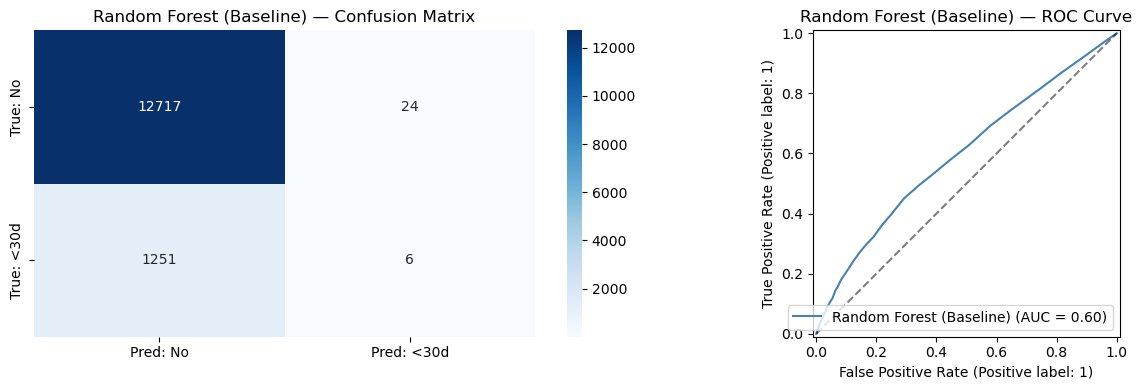

In [4]:
# baseline: 100 trees, no depth limit, class_weight='balanced' for imbalance
rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
print('Baseline RF trained')

baseline_metrics = evaluate_model(rf_base, X_test, y_test,
                                  'Random Forest (Baseline)', save_path='../Results/RF_Results/rf_baseline_eval.png')

## 4. Hyperparameter Tuning (GridSearchCV)

Tuning three main things:
- `n_estimators` — number of trees (more = more stable but slower)
- `max_depth` — how deep each tree can grow. `None` = no limit which can overfit
- `min_samples_split` — minimum samples to split a node. Higher = more conservative

Important: we set `n_jobs=1` in GridSearchCV because each RF already uses all cores (`n_jobs=-1` on the estimator). If we parallelize both, it spawns way too many processes and the kernel crashes — learned that the hard way.

In [5]:
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# n_jobs=1 here to avoid nested parallelism crash (see note above)
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV F1:  {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1:  0.2150


## 5. Tuned RF — Evaluation on Test Set


Random Forest (Tuned)
  Accuracy  : 0.7317
  Precision : 0.1503
  Recall    : 0.4272
  F1 Score  : 0.2224
  ROC-AUC   : 0.6336

                precision    recall  f1-score   support

Not Readmitted       0.93      0.76      0.84     12741
Readmitted <30       0.15      0.43      0.22      1257

      accuracy                           0.73     13998
     macro avg       0.54      0.59      0.53     13998
  weighted avg       0.86      0.73      0.78     13998

Saved: rf_tuned_eval.png


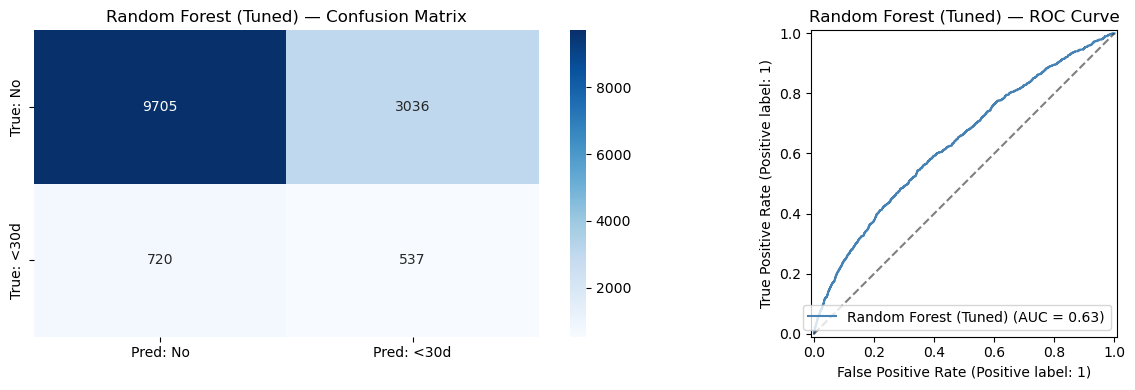

In [6]:
best_rf = grid_search.best_estimator_
tuned_metrics = evaluate_model(best_rf, X_test, y_test,
                               'Random Forest (Tuned)', save_path='../Results/RF_Results/rf_tuned_eval.png')

## 6. Cross-Validation on Tuned Model

5-Fold CV F1 scores: [0.21355568 0.20838899 0.22435233 0.20678685 0.22210095]
Mean: 0.2150 +/- 0.0071


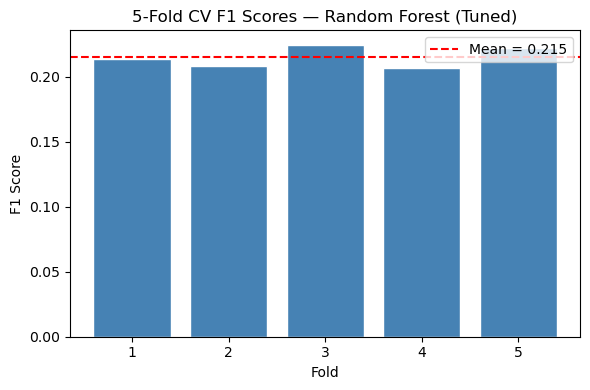

In [7]:
# run 5-fold CV on the final tuned model to see how stable it is
# low std = consistent performance, not just lucky on one split
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='f1', n_jobs=1)

print(f'5-Fold CV F1 scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('5-Fold CV F1 Scores — Random Forest (Tuned)')
plt.legend()
plt.tight_layout()
plt.savefig('../Results/RF_Results/rf_cv_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance

RF gives us Gini importance for free — basically how much each feature helps make the splits purer across all the trees.

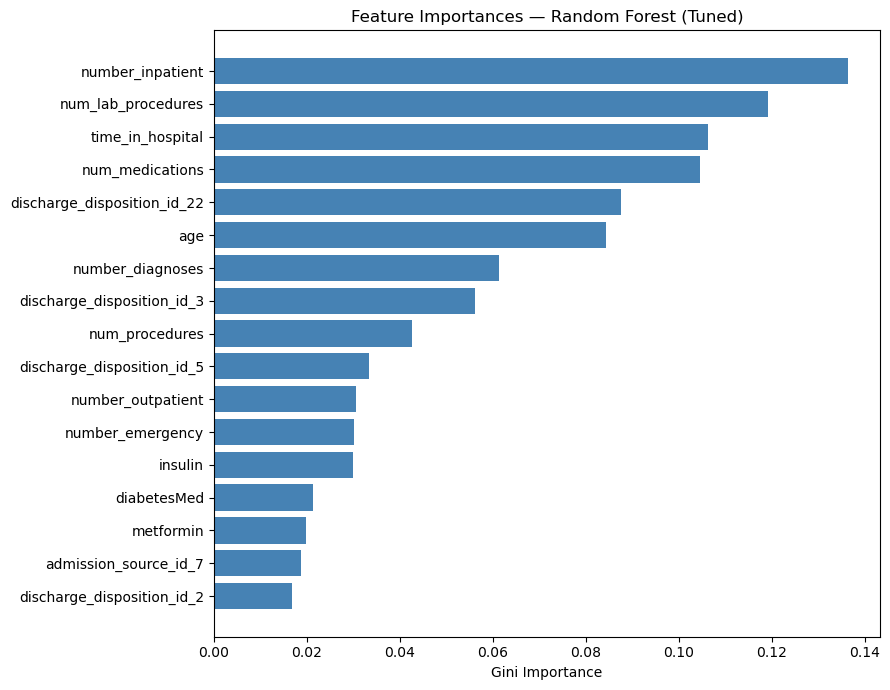


Feature importances:
                    feature  importance
           number_inpatient    0.136497
         num_lab_procedures    0.119243
           time_in_hospital    0.106413
            num_medications    0.104541
discharge_disposition_id_22    0.087682
                        age    0.084454
           number_diagnoses    0.061415
 discharge_disposition_id_3    0.056169
             num_procedures    0.042651
 discharge_disposition_id_5    0.033452
          number_outpatient    0.030681
           number_emergency    0.030060
                    insulin    0.029906
                diabetesMed    0.021439
                  metformin    0.019867
      admission_source_id_7    0.018726
 discharge_disposition_id_2    0.016803


In [8]:
importances = best_rf.feature_importances_
feat_df = pd.DataFrame({'feature': top_features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

plt.figure(figsize=(9, 7))
plt.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color='steelblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importances — Random Forest (Tuned)')
plt.tight_layout()
plt.savefig('../Results/RF_Results/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature importances:')
print(feat_df.to_string(index=False))

## 8. Experiment: Interaction Features

Trees can kind of learn interactions on their own (split on feature A, then split on feature B), so adding explicit interaction terms probably won't help RF as much as it helps something like logistic regression. But we test the same ones from the LR notebook just to see.

In [9]:
# same interaction features used in the LR notebook
interactions = {
    'inpatient_x_medications': ('number_inpatient', 'num_medications'),
    'inpatient_x_time':        ('number_inpatient', 'time_in_hospital'),
    'age_x_diagnoses':         ('age',              'number_diagnoses'),
    'age_x_inpatient':         ('age',              'number_inpatient'),
    'insulin_x_inpatient':     ('insulin',          'number_inpatient'),
}

X_train_inter = X_train.copy()
X_test_inter  = X_test.copy()

for name, (a, b) in interactions.items():
    X_train_inter[name] = X_train_inter[a] * X_train_inter[b]
    X_test_inter[name]  = X_test_inter[a]  * X_test_inter[b]

print(f'Features with interactions: {X_train_inter.shape[1]} (was {X_train.shape[1]})')
print('Added:', list(interactions.keys()))

Features with interactions: 22 (was 17)
Added: ['inpatient_x_medications', 'inpatient_x_time', 'age_x_diagnoses', 'age_x_inpatient', 'insulin_x_inpatient']



Random Forest (Tuned + Interactions)
  Accuracy  : 0.7211
  Precision : 0.1447
  Recall    : 0.4288
  F1 Score  : 0.2164
  ROC-AUC   : 0.6276

                precision    recall  f1-score   support

Not Readmitted       0.93      0.75      0.83     12741
Readmitted <30       0.14      0.43      0.22      1257

      accuracy                           0.72     13998
     macro avg       0.54      0.59      0.52     13998
  weighted avg       0.86      0.72      0.78     13998

Saved: rf_interactions_eval.png


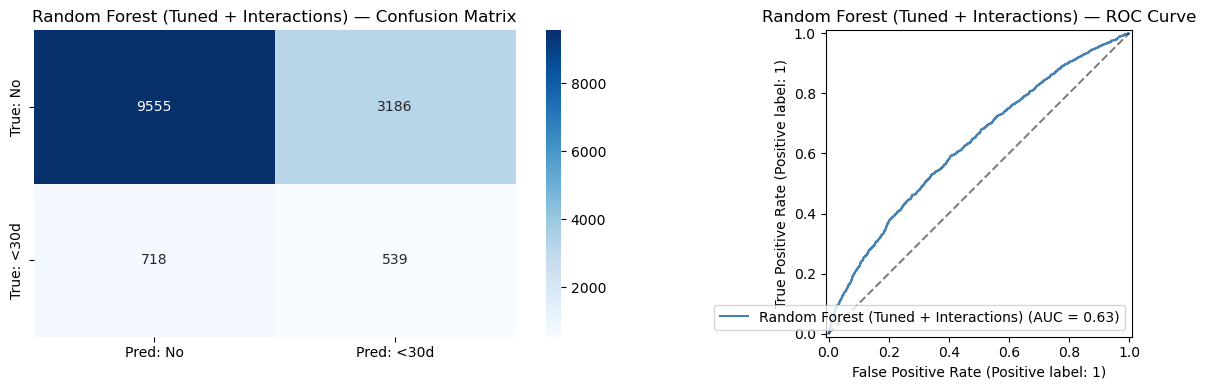

In [10]:
# train RF with best params on interaction features
rf_inter = RandomForestClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_inter.fit(X_train_inter, y_train)

inter_metrics = evaluate_model(rf_inter, X_test_inter, y_test,
                               'Random Forest (Tuned + Interactions)',
                               save_path='../Results/RF_Results/rf_interactions_eval.png')

## 9. Summary

                         accuracy      f1  precision  recall  roc_auc
Model                                                                
RF Baseline                0.9089  0.0093     0.2000  0.0048   0.5957
RF Tuned                   0.7317  0.2224     0.1503  0.4272   0.6336
RF Tuned + Interactions    0.7211  0.2164     0.1447  0.4288   0.6276


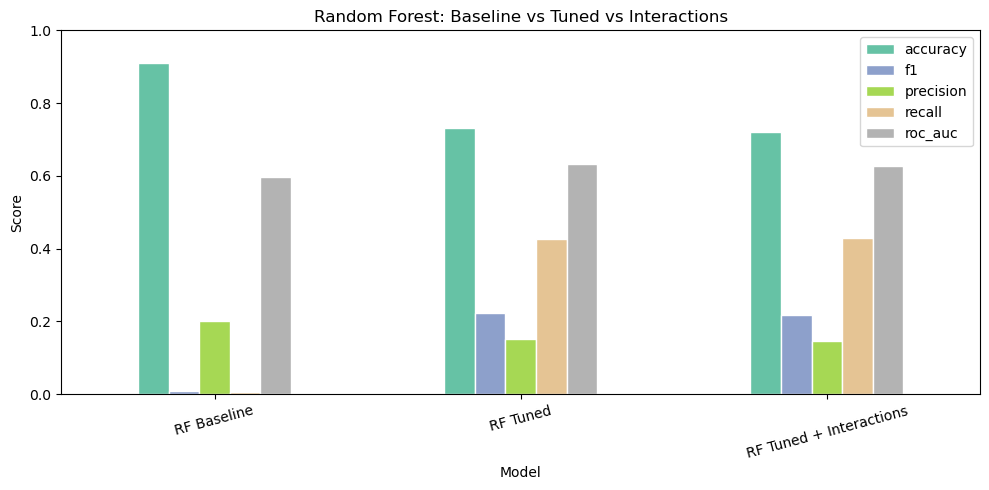

In [11]:
summary = pd.DataFrame([
    {'Model': 'RF Baseline',              **baseline_metrics},
    {'Model': 'RF Tuned',                 **tuned_metrics},
    {'Model': 'RF Tuned + Interactions',  **inter_metrics},
]).set_index('Model').round(4)

print(summary.to_string())

summary.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Random Forest: Baseline vs Tuned vs Interactions')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../Results/RF_Results/rf_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key Findings

- Baseline RF with 100 trees and `class_weight='balanced'` is a decent starting point but tuning helps
- `max_depth=10` seems to be the sweet spot — unlimited depth just overfits to the majority class
- Top features are the same ones we keep seeing everywhere: `number_inpatient`, `time_in_hospital`, discharge disposition codes, `num_medications`
- Adding interaction features didn't really change anything for RF, which makes sense since trees can already pick up on those patterns through splits
- CV scores are pretty stable across folds so the model isn't just getting lucky on one split
- F1 in the 0.22-0.27 range is about what other people get on this dataset too